选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择vip法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择vip法
选择vip法
选择回归系数法
选择回归系数法
选择回归系数法
选择vip法
选择回归系数法
选择vip法
选择回归系数法
回归系数最大波段： 157


<Figure size 1920x1440 with 0 Axes>

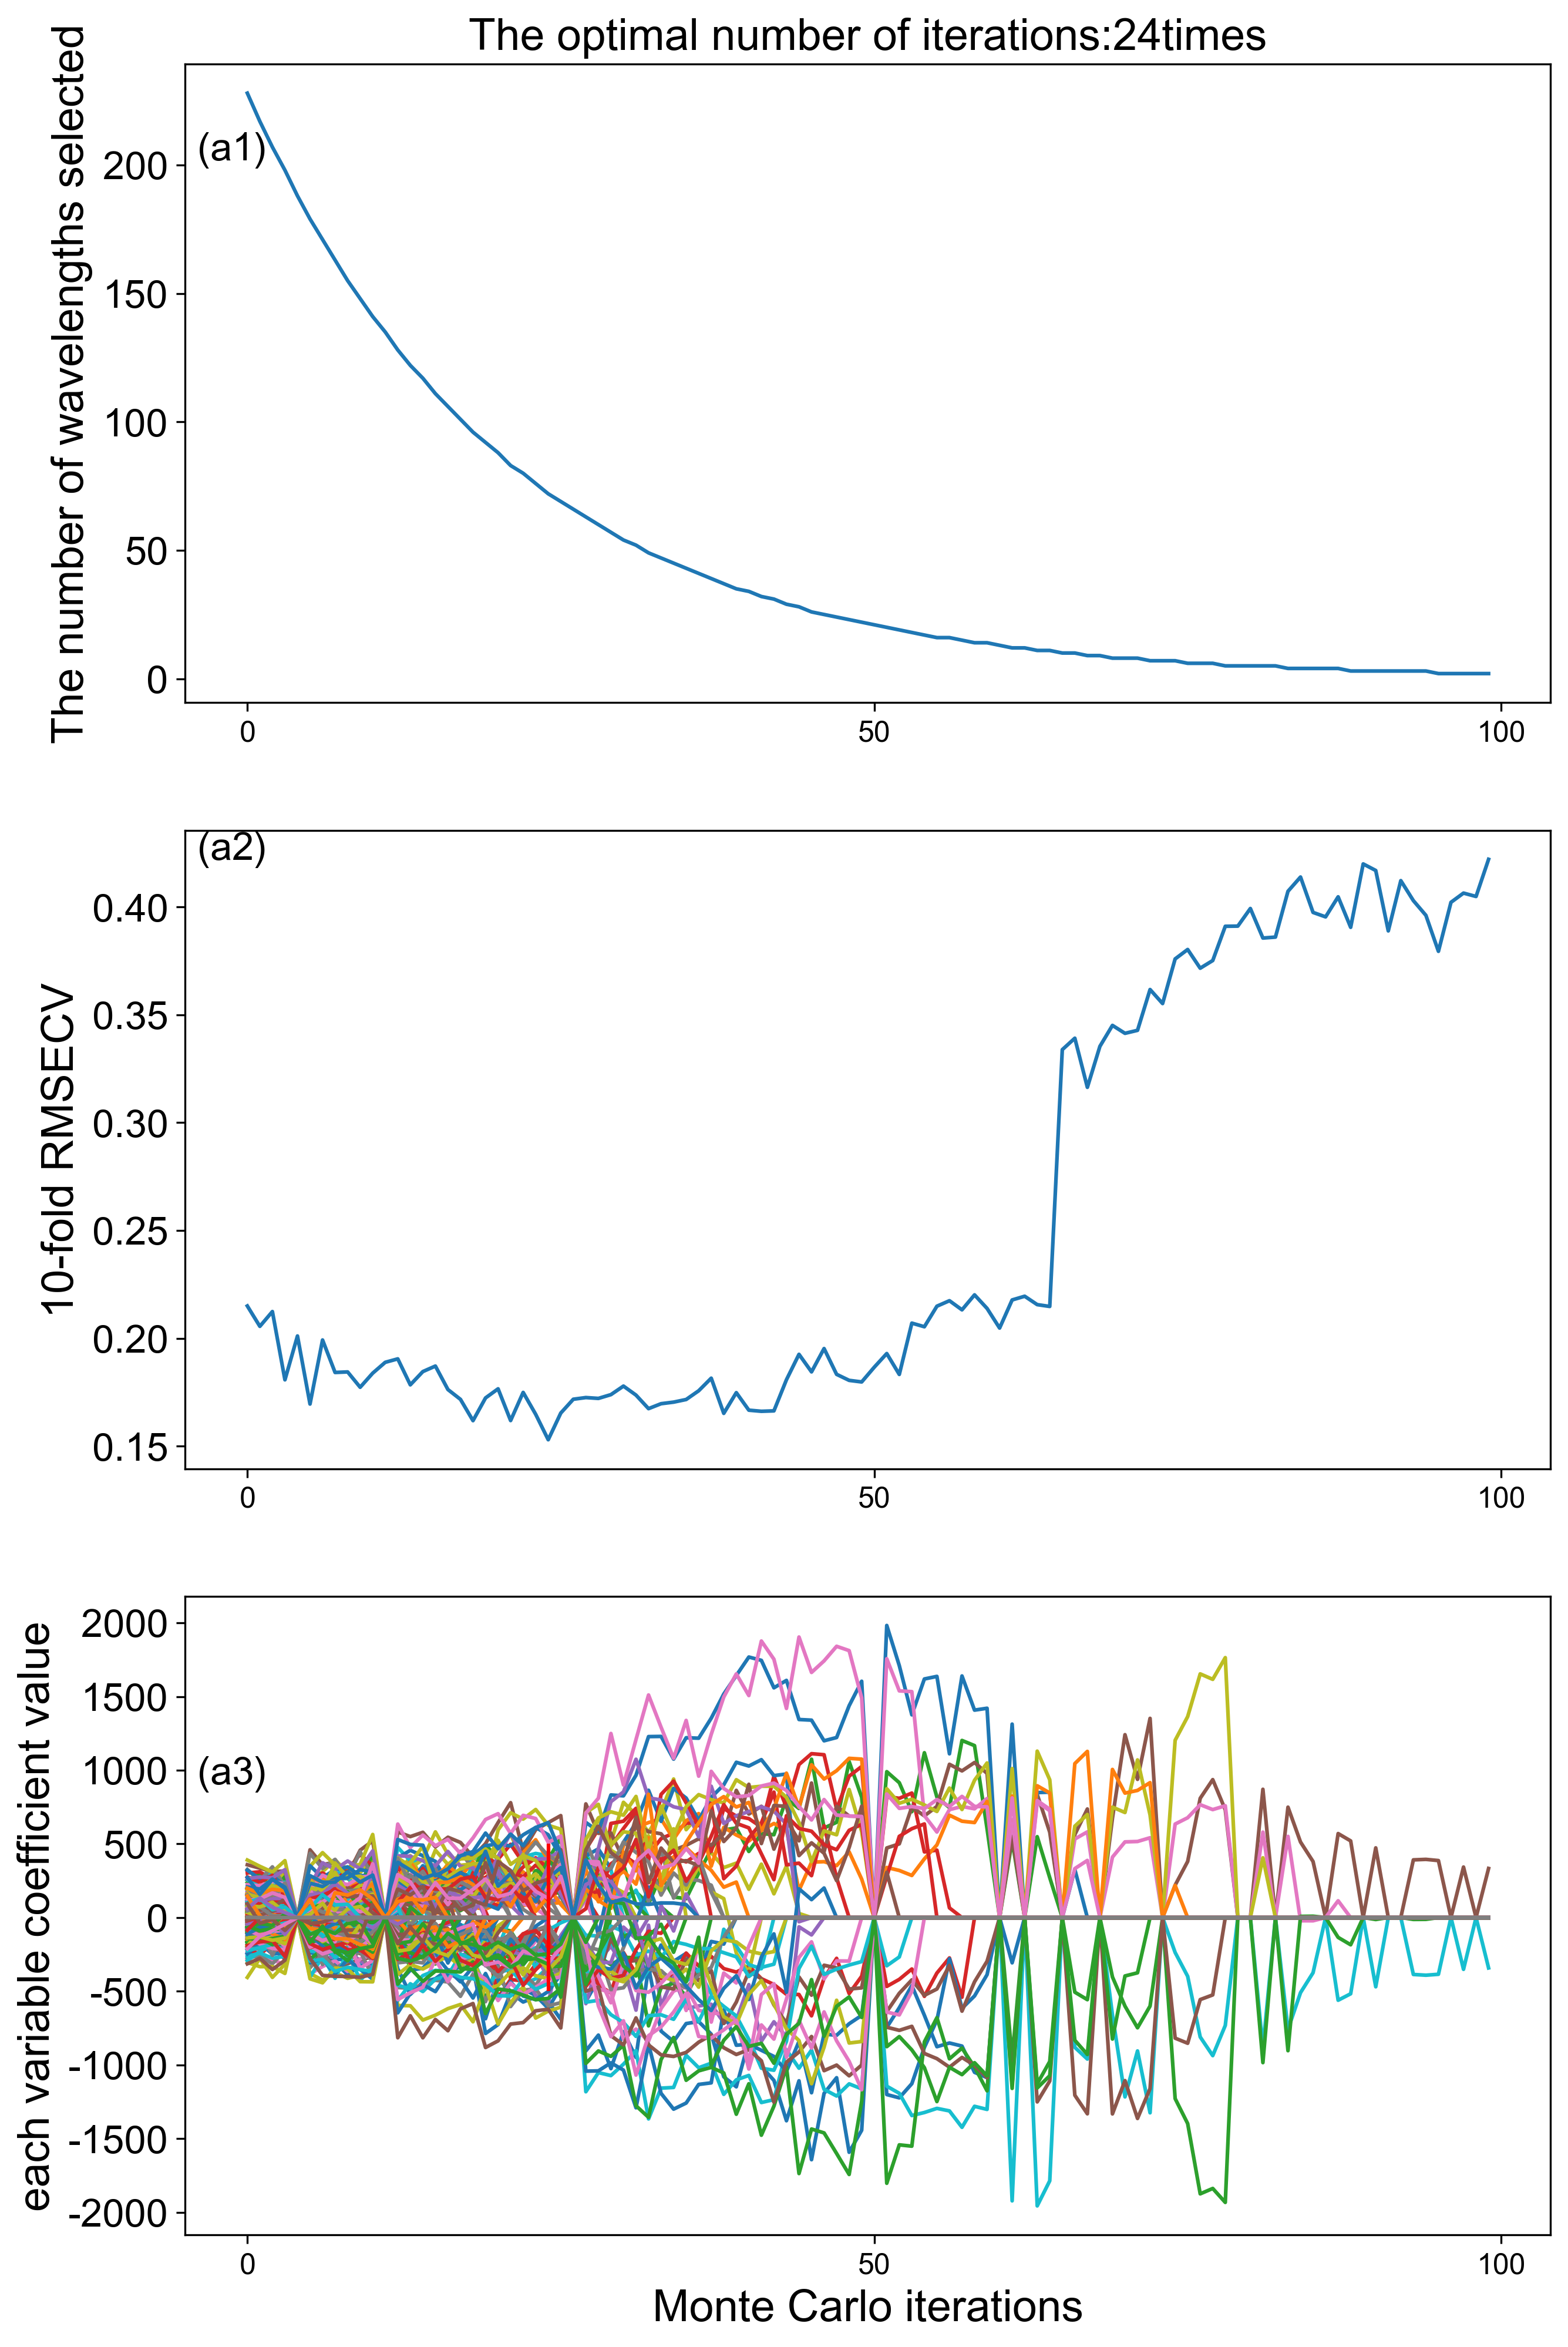

0.15296742454996212
72


In [1]:
import copy
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import scipy.io as scio
import pandas as pd
from sklearn.model_selection import cross_val_predict,LeaveOneOut,cross_val_predict
from sys import stdout
# 设置显示中文字体，
from pylab import mpl
import math
# 设置font.sans-serif 或 font.family 均可
mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  ## mac
plt.rcParams['font.family'] = ['Arial Unicode MS']  ## mac
# 设置正常显示符号
mpl.rcParams["axes.unicode_minus"] = False
import warnings

warnings.filterwarnings(action='ignore')  # 忽略告警
plt.rcParams['font.sans-serif']=['SimSun']
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300
#=======================================================================================================================
#========================================================后向选择=========================================================
def base_pls_cv(X, y, n_components, return_model=False):
    # Simple PLS
    pls_simple = PLSRegression(n_components=n_components)
    # Fit
    pls_simple.fit(X, y)
    # Cross-validation
    y_cv = cross_val_predict(pls_simple, X, y, cv=10)

    # Calculate scores
    score = r2_score(y, y_cv)
    rmsecv = np.sqrt(mean_squared_error(y, y_cv))

    if return_model == False:
        return (y_cv, score, rmsecv)
    else:
        return (y_cv, score, rmsecv, pls_simple)


def pls_optimise_components(X, y, npc):
    rmsecv = np.zeros(npc)
    for i in range(1, npc + 1, 1):
        # Simple PLS
        pls_simple = PLSRegression(n_components=i)
        # Fit
        pls_simple.fit(X, y)
        # Cross-validation
        y_cv = cross_val_predict(pls_simple, X, y, cv=10)

        # Calculate scores
        score = r2_score(y, y_cv)
        rmsecv[i - 1] = np.sqrt(mean_squared_error(y, y_cv))

    # Find the minimum of ther RMSE and its location
    opt_comp, rmsecv_min = np.argmin(rmsecv), rmsecv[np.argmin(rmsecv)]

    return (opt_comp + 1, rmsecv_min)

def houxiang_pls(X,y,n,init_x):
    Xr_optim = X.copy()
    wlr_optim = np.linspace(0, X.shape[1], X.shape[1])

    rmscv_min = 0.6 # Initialise to the baseline value
    #iter_max = n
    iter_max = n
    a = 15
    for rep in range(iter_max):
        rmscv = []
        r2 = []
        loo = LeaveOneOut()
        print(Xr_optim.shape)
        for train_wl, test_wl in loo.split(wlr_optim):

            opt_comp, rmsecv_min = pls_optimise_components(Xr_optim[:, train_wl], y, a if a<len(train_wl) else len(train_wl)-1)
            predicted, r2cv_loo, rmscv_loo = base_pls_cv(Xr_optim[:, train_wl], y, opt_comp)
            rmscv.append(rmscv_loo)
            r2.append(r2cv_loo)

            stdout.write("\r" + str(test_wl))
            stdout.write(" ")
            stdout.write(" %1.4f" % rmscv_loo)
            stdout.write(" ")
            stdout.write(" %1.4f" % r2cv_loo)
            stdout.write(" ")
            stdout.flush()

        new_rmscv = np.min(np.array(rmscv))
        stdout.write('\r')

        # print(rep, np.argmin(np.array(rmscv)), np.min(np.array(rmscv)), np.array(r2)[np.argmin(np.array(rmscv))] )
        print("Rep: %1d,  Deleted band: %1d, RMSCV: %1.4f, R^2: %1.4f " \
              % (rep, np.argmin(np.array(rmscv)), np.min(np.array(rmscv)), np.array(r2)[np.argmin(np.array(rmscv))]))
        if new_rmscv < rmscv_min:
            rmscv_min = new_rmscv
            Xr_optim = np.delete(Xr_optim, np.argmin(np.array(rmscv)), axis=1)
            wlr_optim = np.delete(wlr_optim, np.argmin(np.array(rmscv)))
        else:
            print("End of optimisation at step ", rep)
            break
    ll = []
    for i in range(Xr_optim.shape[1]):
        for j in range(init_x.shape[1]):
            if (Xr_optim[:,i]==init_x[:,j]).all():
                ll.append(j)
    print('errr',ll,len(ll))
    return ll,rmscv_min
#=======================================================================================================================
#========================================================Cars===========================================================
def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        PRESS :各主成分数对应的PRESS
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1,scale=False)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex

def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
     RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc,scale=False)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean

def CARS_Cloud(X, y, N=100, f=20, cv=10):
    p = 0.8
    m, n = X.shape
    u = np.power((n/2), (1/(N-1)))
    k = (1/(N-1)) * np.log(n/2)
    cal_num = np.round(m * p)
    x = copy.deepcopy(X)
    WaveData = []
    Coeff = []
    WaveNum =[]
    RMSECV = []
    r = []
    for i in range(1, N+1):
        r.append(u*np.exp(-1*k*i))
        wave_num = int(np.round(r[i-1]*n))
        WaveNum = np.hstack((WaveNum, wave_num))
        cal_index = np.random.choice(np.arange(m), size=int(cal_num), replace=False)
        x_init = X[cal_index,:]
        ycal = y[cal_index]
        if f>= x.shape[1]:
            f = x.shape[1]
        pls = PLSRegression(n_components=f, scale=False)
        pls.fit(x[cal_index,:], ycal)
        '''
        回归系数排序
        '''
        beta = pls.coef_
        b = np.abs(beta)
        hh = np.squeeze(np.argsort(-b, axis=0))
        x_cars = x[cal_index,:][:,hh][:,:wave_num]
        if f >= x_cars.shape[1]:
            f = x_cars.shape[1]
        rmsecv, rindex = PC_Cross_Validation(x_cars, ycal, f, cv)
        RMSECV_cars = Cross_Validation(x_cars, ycal, rindex + 1, cv)
        '''
        VIP值排序
        '''
        W = pls.x_weights_
        T = pls.x_scores_
        P = pls.x_loadings_
        V = np.dot(np.dot(P, np.diag(1 / np.diag(np.dot(P.T, P)))), P.T)
        V = np.dot(V, W)
        s = np.diag(np.dot(np.dot(T.T, T), np.dot(W.T, W)))
        s_vip = np.sqrt(len(s) * s / np.sum(s))
        vip_scores = np.dot(V ** 2, s_vip)
        ss = np.argsort(-vip_scores, axis=0)
        x_vip = x[cal_index, :][:, ss][:, :wave_num]
        if f >= x_vip.shape[1]:
            f = x_vip.shape[1]
        rmsecv, rindex = PC_Cross_Validation(x_vip, ycal, f, cv)
        RMSECV_vip = Cross_Validation(x_vip, ycal, rindex + 1, cv)

        if RMSECV_vip<RMSECV_cars:
            print('选择vip法')
            RMSECV.append(RMSECV_vip)
            ll = []
            for i in range(x_vip.shape[1]):
                for j in range(x_init.shape[1]):
                    if (x_vip[:, i] == x_init[:, j]).all():
                        ll.append(j)
            WaveData.append(ll)
            Coeff.append(vip_scores[ss][:wave_num])
            x = x[:, ss][:, :wave_num]

        else:
            print('选择回归系数法')
            RMSECV.append(RMSECV_cars)
            ll = []
            for i in range(x_cars.shape[1]):
                for j in range(x_init.shape[1]):
                    if (x_cars[:, i] == x_init[:, j]).all():
                        ll.append(j)
            WaveData.append(ll)
            Coeff.append(beta[hh][:wave_num])
            x = x[:,hh][:,:wave_num]

    COEFF = np.zeros((N,X.shape[1]))
    for i in range(N):
        for j in range(len(WaveData[i])):
            COEFF[i,WaveData[i][j]] = Coeff[i][j]

    MinIndex = np.argmin(RMSECV)
    OptWave = WaveData[MinIndex]

    fig = plt.figure()
    plt.figure(figsize=(10, 16))
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
    fonts = 18
    plt.subplot(311)
    plt.text(-4, 170, "(a1)\n\n", fontsize=16, color='black')
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 50)
    plt.xticks(x_ticks,fontsize=12)
    plt.yticks(fontsize=16)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('The number of wavelengths selected', fontsize=fonts)
    plt.title('The optimal number of iterations:' + str(MinIndex) + 'times', fontsize=fonts)
    plt.plot(np.arange(N), WaveNum)
    #
    plt.subplot(312)
    plt.text(-4, 0.91 * max(RMSECV), "(a2)\n\n", fontsize=16, color='black') 
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 50)
    plt.xticks(x_ticks,fontsize=12)
    plt.yticks(fontsize=16)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('10-fold RMSECV', fontsize=fonts)
    plt.plot(np.arange(N), RMSECV)
    #
    plt.subplot(313)
    # 设置刻度的间隔为每隔10一个刻度
    x_ticks = np.arange(0, N+10, 50)
    plt.xticks(x_ticks,fontsize=12)
    plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.yticks(fontsize=16)
    # plt.figure(figsize=(8, 6))
    plt.text(-4, 350, "(a3)\n\n", fontsize=16, color='black')
    # # 设置刻度的间隔为每隔10一个刻度
    # x_ticks = np.arange(0, N + 10, 10)
    # plt.xticks(x_ticks, fontsize=16)
    # plt.yticks(fontsize=16)
    # plt.xlabel('Monte Carlo iterations', fontsize=fonts)
    plt.ylabel('each variable coefficient value', fontsize=fonts)
    init_ess = 0
    bound_index = 0
    for i in range(COEFF.shape[1]):
        if np.average(COEFF[:,i])>init_ess:
            init_ess = np.average(COEFF[:,i])
            bound_index = i
        plt.plot(np.arange(COEFF.shape[0]), COEFF[:, i])
    #plt.plot(np.arange(COEFF.shape[0]), COEFF[:, bound_index], linestyle=(0, (1, 10)), marker='*')
    print('回归系数最大波段：',bound_index+1)
    plt.vlines(MinIndex, -500, 500, colors='r')
    # plt.savefig(r'C:\Users\sjzx_deeplearning_01\Desktop\CARS.png')
    # 保存为TIFF格式
    plt.savefig('/Users/macbook/Desktop/论文原图/a1.tif', format='tiff', dpi=300, bbox_inches='tight')
    # 保存为JPG格式
    plt.savefig('/Users/macbook/Desktop/论文原图/a1.jpg', format='jpg', dpi=300, bbox_inches='tight')
    
    plt.show()
    # print(RMSECV)
    print(min(RMSECV))
    print(len(OptWave))
    # print(MinIndex)
    # plt.savefig(r'/Users/macbook/Downloads/CARS.png')
    return OptWave
#=======================================================================================================================
if __name__ == "__main__":
    data = pd.read_excel(r"/Users/macbook/folder/data/DD.xlsx").values
    y = data[:, 0]
    X = data[:, 1:]
    cars = CARS_Cloud(X, y)
    # print('结果：', cars)

72
[220, 85, 78, 88, 175, 10, 77, 44, 30, 90, 162, 156, 80, 149, 29, 157, 19, 146, 18, 138, 124, 144, 22, 141, 142, 198, 194, 79, 23, 83, 182, 60, 137, 212, 206, 129, 133, 166, 168, 92, 158, 163, 42, 190, 205, 222, 180, 2, 43, 174, 57, 53, 96, 41, 188, 13, 183, 52, 187, 3, 191, 216, 46, 203, 58, 1, 24, 99, 105, 17, 107, 197]
PLS-CARS_train 0.9227987458214865 0.11278153607825249
PLS-CARS_test 0.7851357685696575 0.2019185935652857


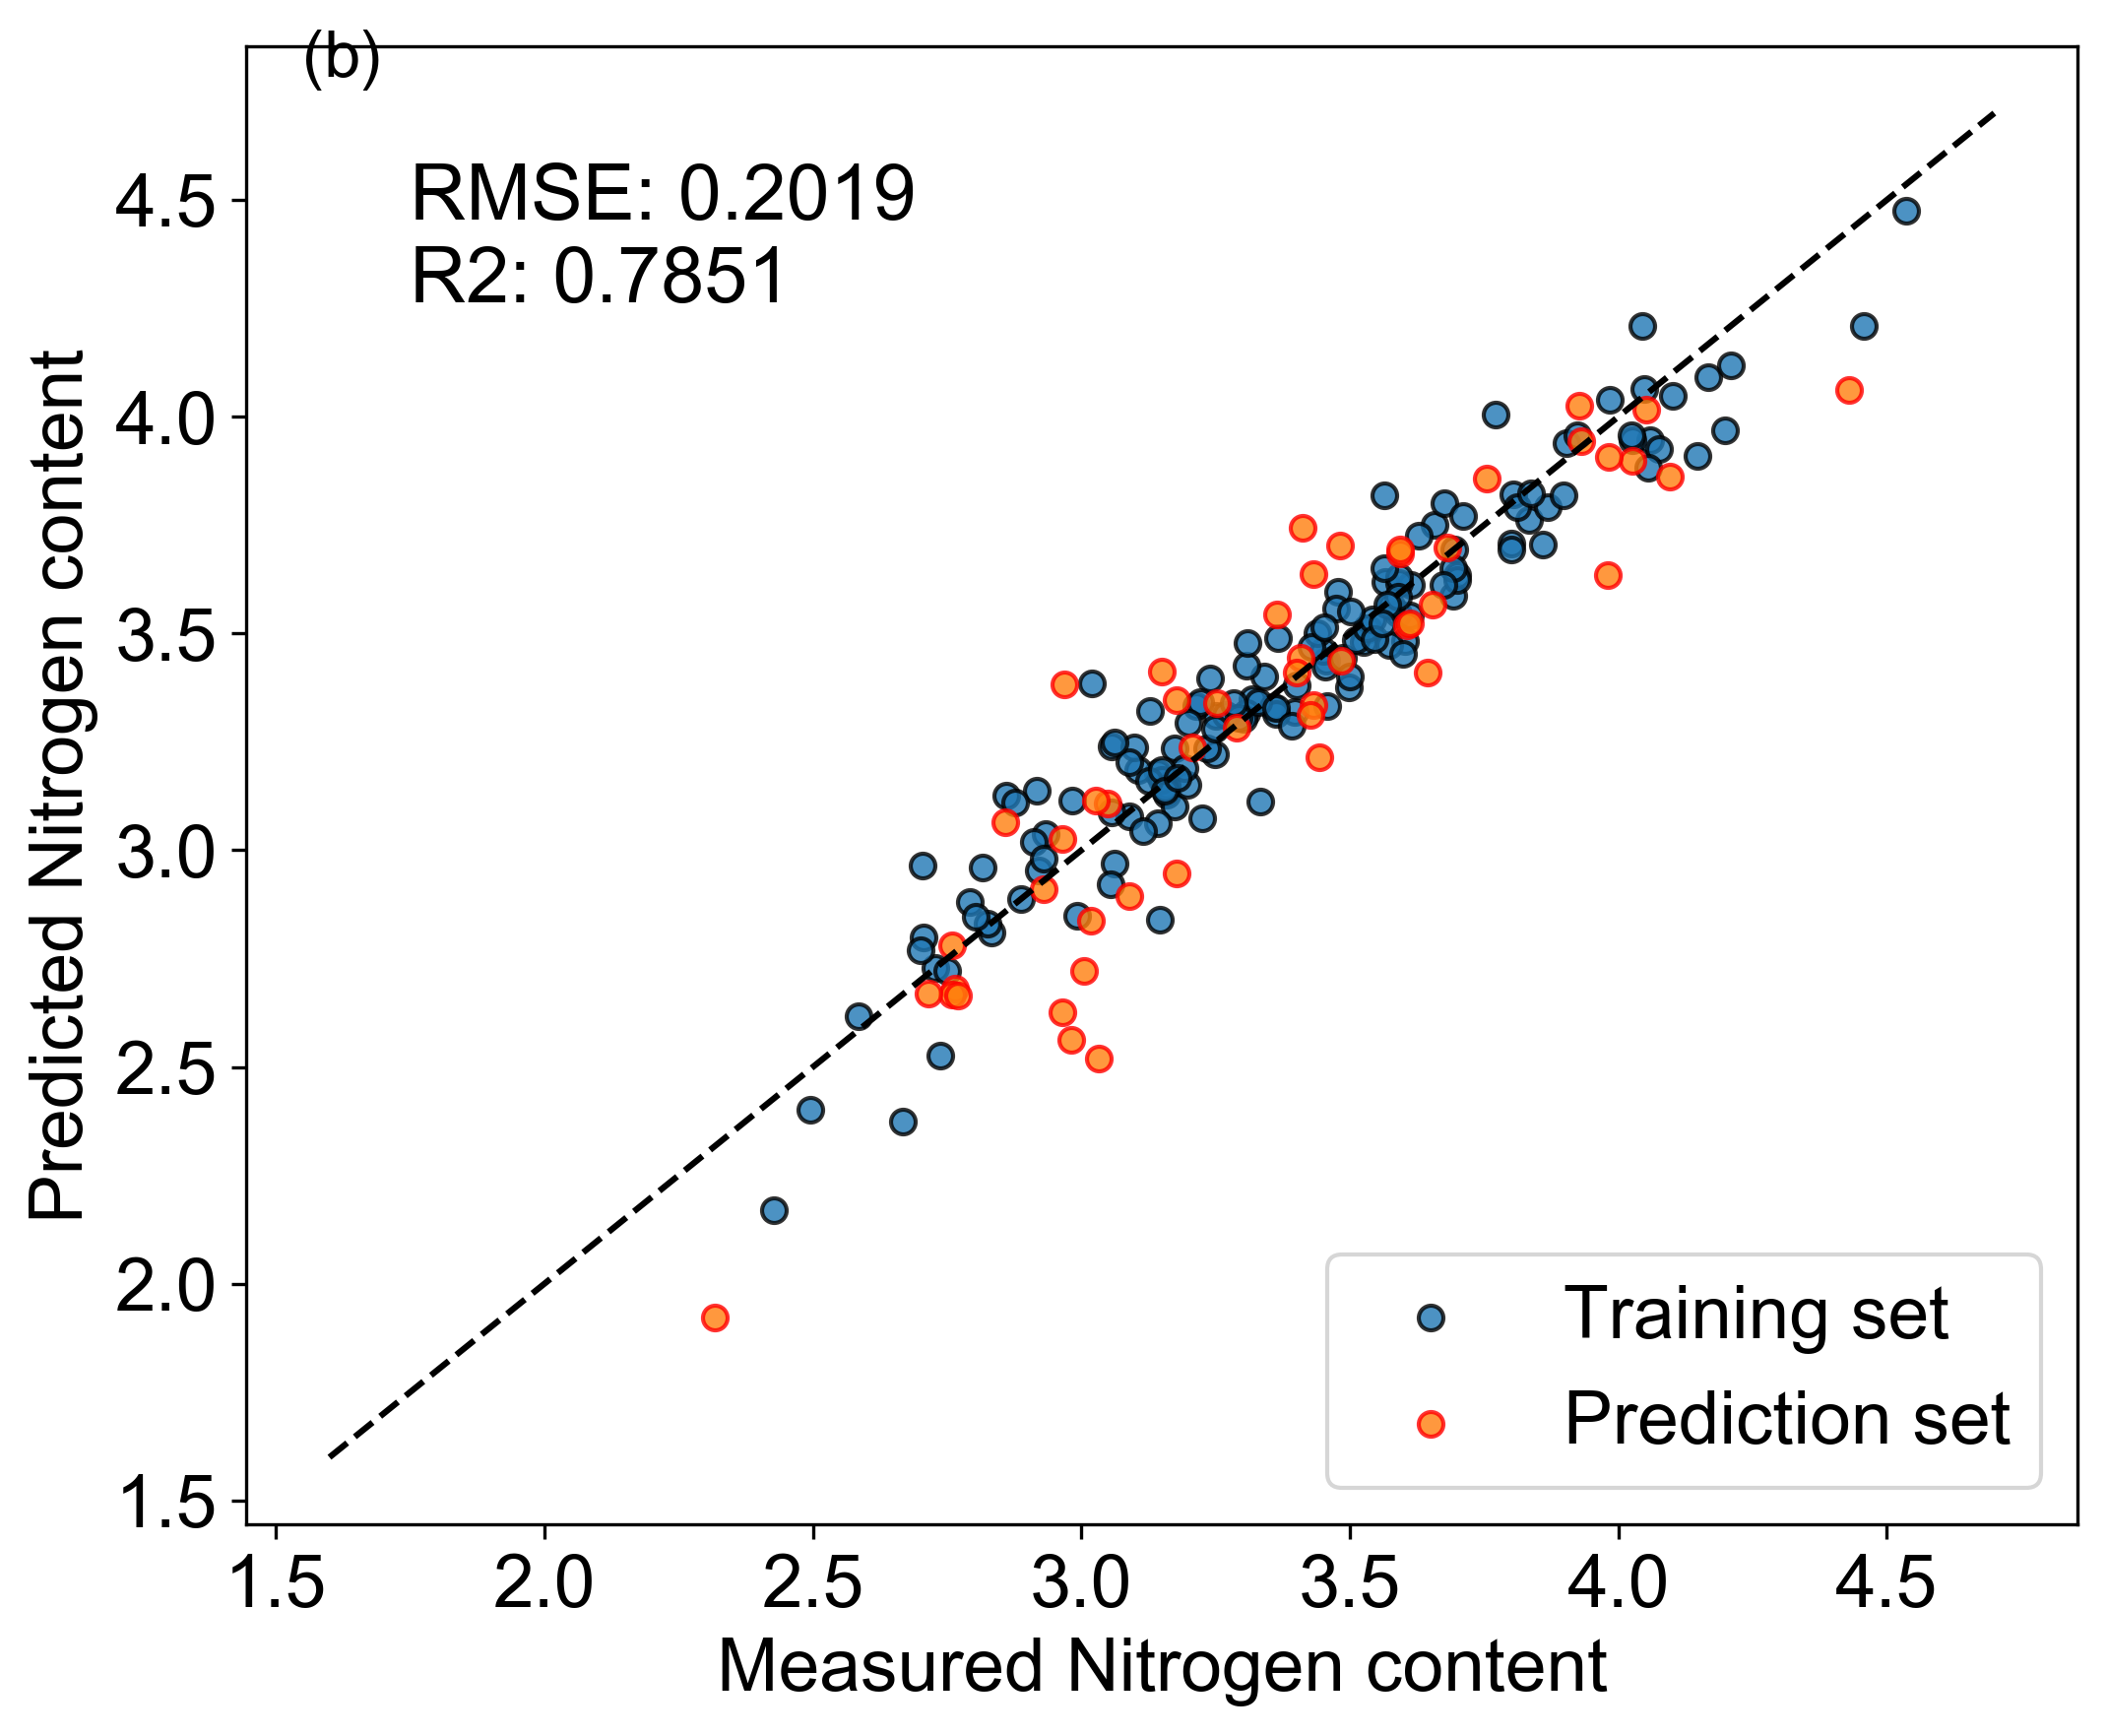

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

data_y = y
data_x = X
best_features = cars
print(len(best_features))
print(best_features)
features_select = []
for i in best_features:
    features_select.append(data_x[:, i])
features_select = np.array(features_select)
features_select = features_select.transpose()
x_train, x_test, y_train, y_test = train_test_split(features_select, data_y, test_size=0.25, random_state=30)

pls_model_setup = PLSRegression(scale=False)
param_grid = {'n_components': range(1, x_train.shape[1])}
gsearch = GridSearchCV(pls_model_setup, param_grid, cv=5)
pls_model = gsearch.fit(x_train, y_train)
# pls_model.fit(x_train, y_train)
pls_y_train = pls_model.predict(x_train)
pls_y_test = pls_model.predict(x_test)
pls_r2_train = r2_score(y_train, pls_y_train)
pls_r2_test = r2_score(y_test, pls_y_test)
pls_rmse_train = np.sqrt(mean_squared_error(y_train, pls_y_train))
pls_rmse_test = np.sqrt(mean_squared_error(y_test, pls_y_test))
print("PLS-CARS_train", pls_r2_train, pls_rmse_train)
print("PLS-CARS_test", pls_r2_test, pls_rmse_test)
boduan = np.linspace(942, 1701, X.shape[1])
newbd = boduan[best_features[:]]
# newbd
import matplotlib

# with plt.style.context(('seaborn-whitegrid')):  
plt.figure(figsize=(8, 6.5))

# x = np.linspace(1.5, 4.5, 7)
# y = np.linspace(1.5, 4.5, 7)

# Scatter plot of X vs Y  
plt.scatter(y_train, pls_y_train, label='Training set', edgecolors='k', alpha=0.8)
plt.scatter(y_test, pls_y_test, label='Prediction set', edgecolors='r', alpha=0.8)

# Plot of the 45 degree line  
plt.plot([1.6, 4.7], [1.6, 4.7], color='black', linestyle='--')
# Create a FontProperties object for the text  
fontprops = matplotlib.font_manager.FontProperties(style='italic')
plt.text(1.55, 1.1 * pls_y_test.max(), "(b)\n\n", fontsize=16, color='black')
title = plt.text(1.75, 1.05 * pls_y_test.max(), "  \nRMSE: {:.4f}\nR2: {:.4f}".format(pls_rmse_test, pls_r2_test),
                 fontsize=19, color='black')
title.set_fontstyle('italic')
plt.grid(False)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.title('PC selection by CARS', fontsize=18)  
plt.xlabel('Measured Nitrogen content', fontsize=18)
plt.ylabel('Predicted Nitrogen content', fontsize=18)

plt.legend(loc='lower right', prop={'size': 18})  # 添加图例并放在右下角，并且设置图例字体大小为16，样式为斜体   

plt.show() 